In [1]:
#instalam librariile in caz ca este necesar
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install pymc
%pip install arviz
%pip install scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from scipy import stats
np.random.seed(74)


exercitiul 1


Dataset shape: (500, 6)
   rentals     temp_c  humidity   wind_kph  is_holiday  season
0      657   7.783223  0.225520  18.057709           0  winter
1      632  16.691937  0.533523  15.975831           0  spring
2      546  17.044212  0.879505  13.235575           1  spring
3      650  18.460255  0.623327  18.159102           1  autumn
4      730  19.841524  0.244849   0.500000           1  summer
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rentals     500 non-null    int64  
 1   temp_c      500 non-null    float64
 2   humidity    500 non-null    float64
 3   wind_kph    500 non-null    float64
 4   is_holiday  500 non-null    int64  
 5   season      500 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 23.6+ KB
None
          rentals      temp_c    humidity    wind_kph  is_holiday
count  500.000000  500.000000  

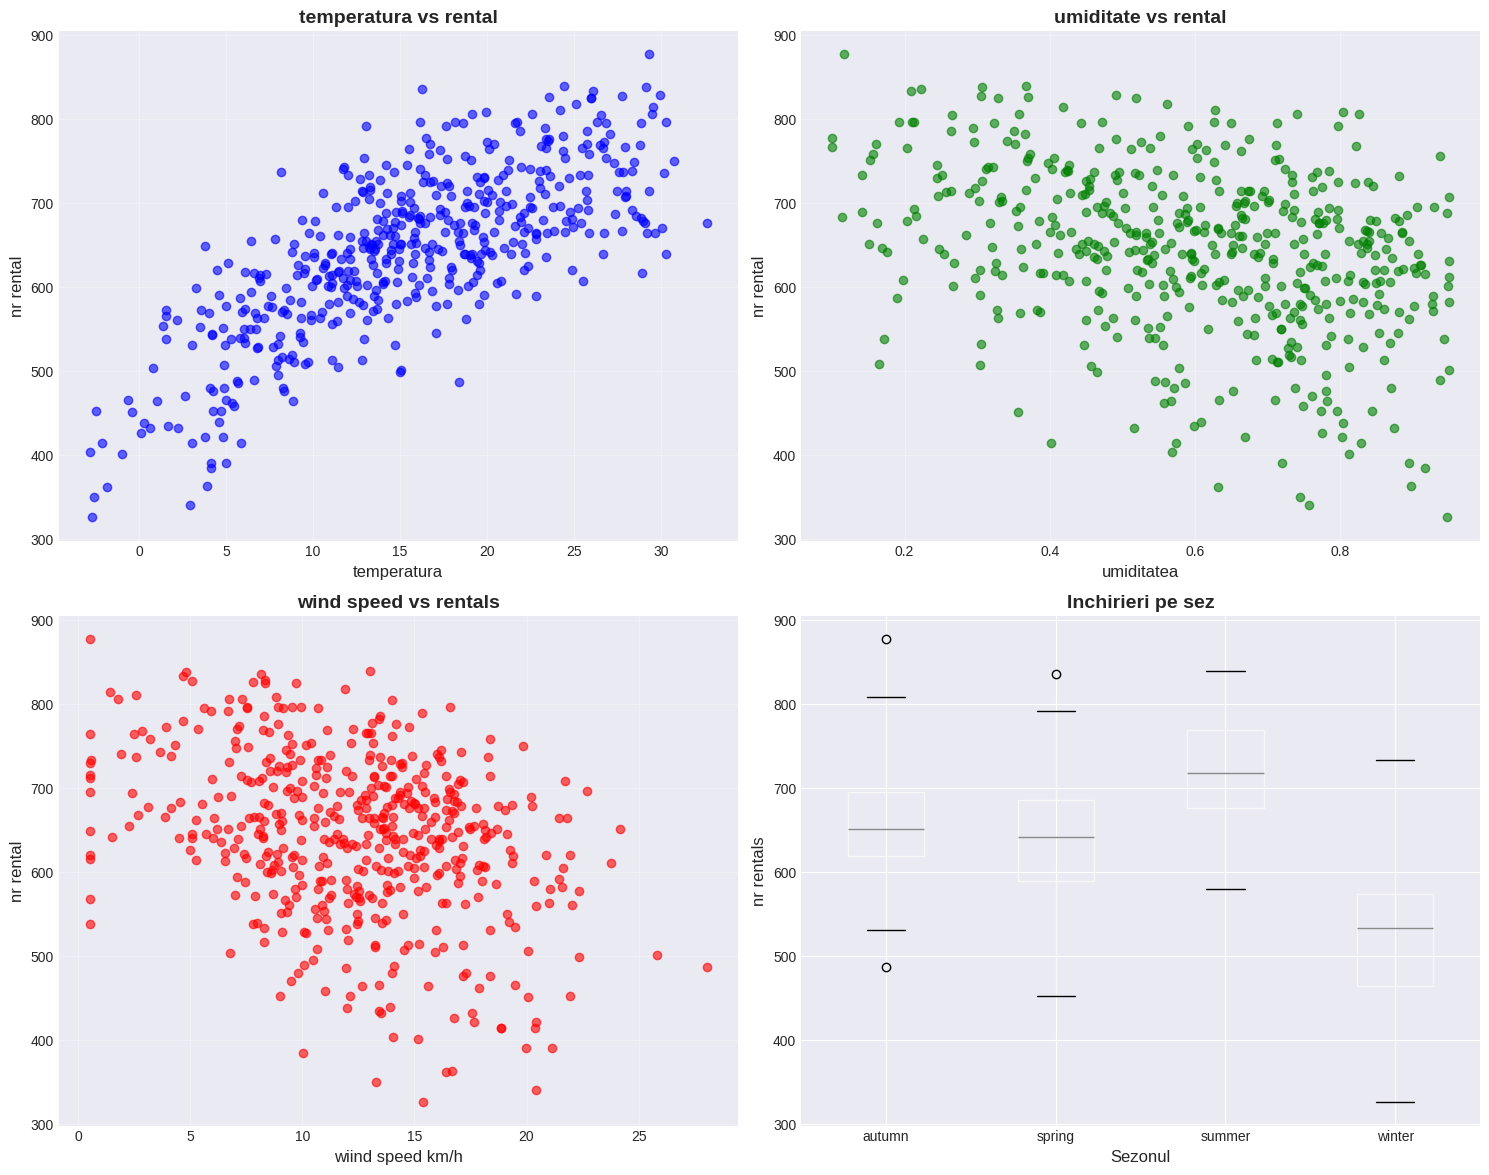

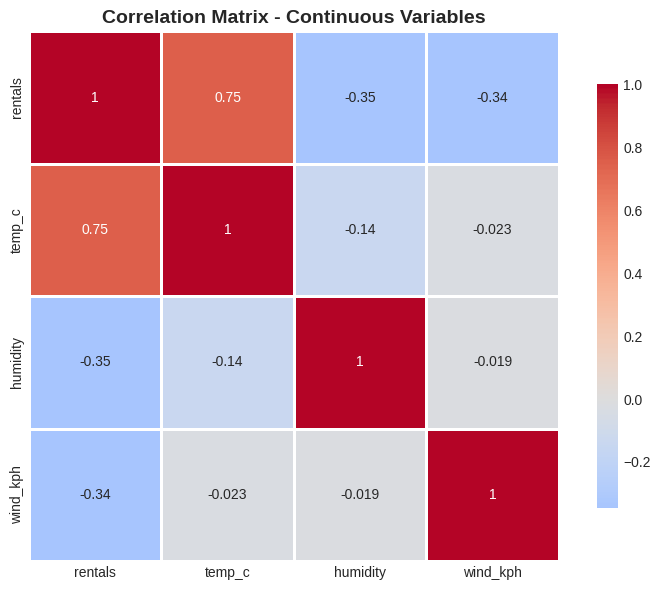

In [3]:
#setari pt grafice
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


#incarcam datasetul
df = pd.read_csv('./bike_daily.csv')

print(f"\nDataset shape: {df.shape}")
print(df.head())
print(df.info())
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nSeason distribution:")
print(df['season'].value_counts())
print(f"\nHoliday distribution:")
print(df['is_holiday'].value_counts())


# exploram relatiile dintre variabile
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# temp vs rental
axes[0, 0].scatter(df['temp_c'], df['rentals'], alpha=0.6, c='blue')
axes[0, 0].set_xlabel('temperatura', fontsize=12)
axes[0, 0].set_ylabel('nr rental', fontsize=12)
axes[0, 0].set_title('temperatura vs rental', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# umiditate vs rental
axes[0, 1].scatter(df['humidity'], df['rentals'], alpha=0.6, c='green')
axes[0, 1].set_xlabel('umiditatea', fontsize=12)
axes[0, 1].set_ylabel('nr rental', fontsize=12)
axes[0, 1].set_title('umiditate vs rental', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# wind speed vs rental
axes[1, 0].scatter(df['wind_kph'], df['rentals'], alpha=0.6, c='red')
axes[1, 0].set_xlabel('wiind speed km/h', fontsize=12)
axes[1, 0].set_ylabel('nr rental', fontsize=12)
axes[1, 0].set_title('wind speed vs rentals', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# boxplot pe sezoane
df.boxplot(column='rentals', by='season', ax=axes[1, 1])
axes[1, 1].set_xlabel('Sezonul', fontsize=12)
axes[1, 1].set_ylabel('nr rentals', fontsize=12)
axes[1, 1].set_title('Inchirieri pe sez', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig('./ex1_exploratory_analysis.png', dpi=300, bbox_inches='tight')

numeric_cols = ['rentals', 'temp_c', 'humidity', 'wind_kph']
correlation_matrix = df[numeric_cols].corr()

print(f"\nCorrelation:")
print(correlation_matrix)
# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Continuous Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./ex1_heatmap.png', dpi=300, bbox_inches='tight')



exercitiul 2


Parametrii de standardizare:
Temperatura: mean=15.49, std=7.59°C
Umiditate: mean=0.5970, std=0.2052
Wind Speed: mean=12.31 km/h, std=4.90 km/h


Output()


rezumatul dupa posterior
                  mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept      641.890  2.235  637.688  646.114      0.021    0.028   11710.0   
beta_temp       69.047  2.254   64.915   73.277      0.021    0.026   11317.0   
beta_humidity  -24.754  2.340  -29.156  -20.304      0.022    0.028   11160.0   
beta_wind      -32.366  2.297  -36.706  -28.110      0.021    0.029   12434.0   
sigma           50.402  1.613   47.401   53.403      0.015    0.020   11171.0   

               ess_tail  r_hat  
intercept        5305.0    1.0  
beta_temp        6536.0    1.0  
beta_humidity    6161.0    1.0  
beta_wind        5661.0    1.0  
sigma            5679.0    1.0  


Output()

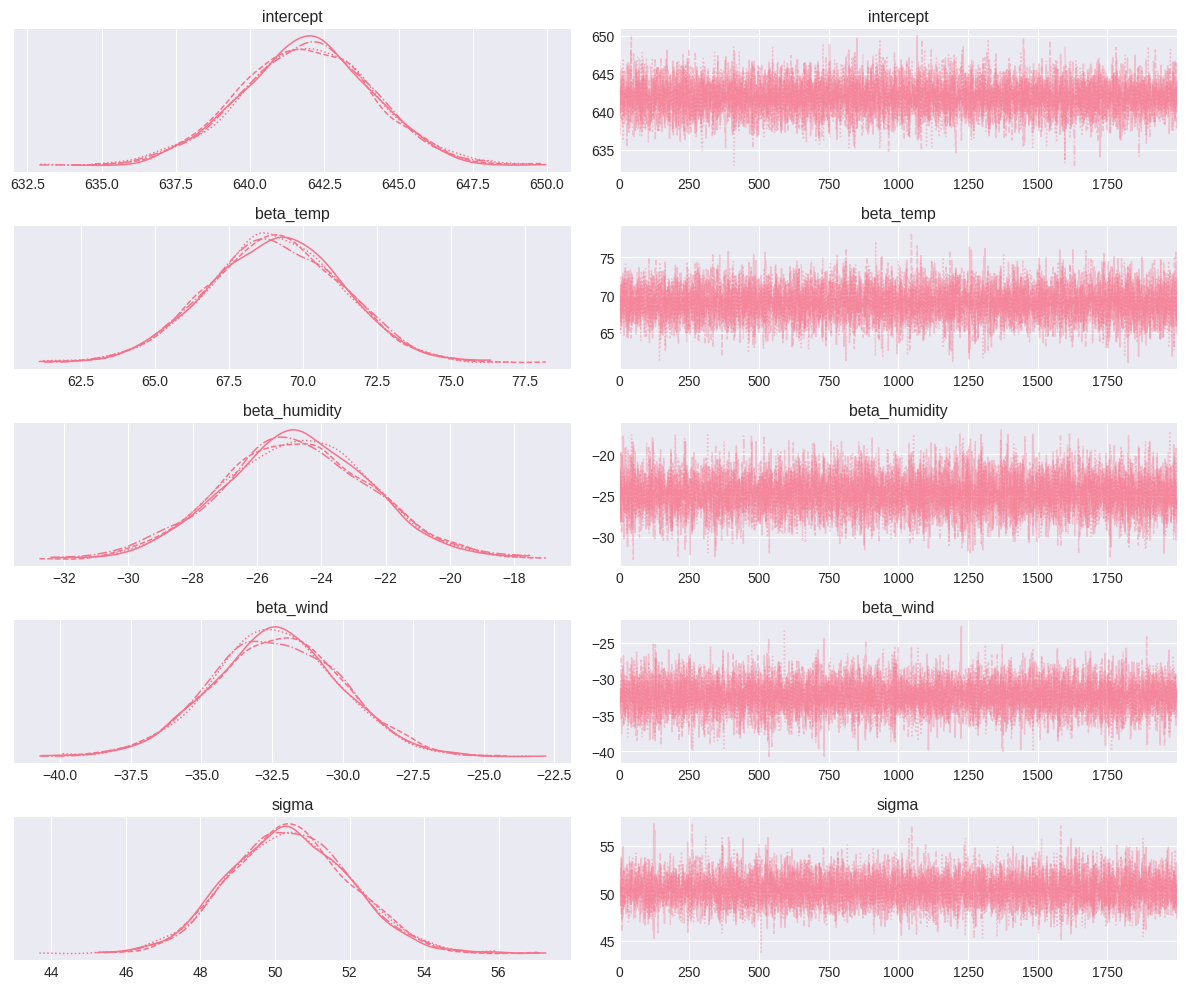

In [4]:
# Prepare data
rentals = df['rentals'].values
temp_c = df['temp_c'].values
humidity = df['humidity'].values
wind_kph = df['wind_kph'].values
is_holiday = df['is_holiday'].values
season_cat = df['season'].astype('category').cat.codes.values

#a

# standarizarea variabilelor continue
temp_c_mean, temp_c_std = temp_c.mean(), temp_c.std()
humidity_mean, humidity_std = humidity.mean(), humidity.std()
wind_kph_mean, wind_kph_std = wind_kph.mean(), wind_kph.std()

temp_c = (temp_c - temp_c_mean) / temp_c_std
humidity = (humidity - humidity_mean) / humidity_std
wind_kph = (wind_kph - wind_kph_mean) / wind_kph_std

print(f"\nParametrii de standardizare:")
print(f"Temperatura: mean={temp_c_mean:.2f}, std={temp_c_std:.2f}°C")
print(f"Umiditate: mean={humidity_mean:.4f}, std={humidity_std:.4f}")
print(f"Wind Speed: mean={wind_kph_mean:.2f} km/h, std={wind_kph_std:.2f} km/h")


# print(f"Temp_c_std: mean={temp_c.mean():.6f}, std={temp_c.std():.6f}")
# print(f"Humidity_std: mean={humidity.mean():.6f}, std={humidity.std():.6f}")
# print(f"Wind_kph_std: mean={wind_kph.mean():.6f}, std={wind_kph.std():.6f}")

# b

#construim modelul liniar

with pm.Model() as linear_model:
    intercept = pm.Normal('intercept', mu=0, sigma=100)
    beta_temp = pm.Normal('beta_temp', mu=0, sigma=50)
    beta_humidity = pm.Normal('beta_humidity', mu=0, sigma=50)
    beta_wind = pm.Normal('beta_wind', mu=0, sigma=50)


    m = intercept + beta_temp * temp_c + beta_humidity * humidity + beta_wind * wind_kph
    #prior
    sigma = pm.HalfNormal('sigma', sigma=100)
    #likelihood
    rentals_obs = pm.Normal('rentals_obs', mu=m, sigma=sigma, observed=rentals)

    #facem sampling (posterior)
    trace_linear = pm.sample(2000, tune=1000, chains=4, random_seed=42,
                             return_inferencedata=True, target_accept=0.95)
#rezumatul dupa posterior
print("\nrezumatul dupa posterior")
print(az.summary(trace_linear, var_names=['intercept', 'beta_temp', 'beta_humidity', 'beta_wind', 'sigma']))

# Plot posterior distributions
az.plot_trace(trace_linear, var_names=['intercept', 'beta_temp', 'beta_humidity', 'beta_wind', 'sigma'])
plt.tight_layout()
plt.savefig('./ex2b.png', dpi=300, bbox_inches='tight')

# c

#construim modelul

temp_c2 = temp_c ** 2

with pm.Model() as poly_model:
    # priors pentru coeficienti
    intercept = pm.Normal('intercept', mu=0, sigma=100)
    beta_temp = pm.Normal('beta_temp', mu=0, sigma=50)
    beta_temp_sq = pm.Normal('beta_temp_sq', mu=0, sigma=50)
    beta_humidity = pm.Normal('beta_humidity', mu=0, sigma=50)
    beta_wind = pm.Normal('beta_wind', mu=0, sigma=50)


    m = (intercept +
          beta_temp * temp_c +
          beta_temp_sq * temp_c2 +
          beta_humidity * humidity +
          beta_wind * wind_kph)

    #prior pentru anomalii si noise
    sigma = pm.HalfNormal('sigma', sigma=100)

    #likelihood
    rentals_obs = pm.Normal('rentals_obs', mu=m, sigma=sigma, observed=rentals)

    trace_poly = pm.sample(2000, tune=1000, chains=4, random_seed=42,
                           return_inferencedata=True, target_accept=0.95)


exercitiul 4

In [5]:
#A

#WAIC pt ambele modele
waic_linear = az.waic(trace_linear)
waic_poly = az.waic(trace_poly)

print(f"\nWAIC pt modelul liniar {waic_linear.waic:.2f}, p_WAIC: {waic_linear.p_waic:.2f}")
print(f"WAIC pt modelul polinomial {waic_poly.waic:.2f}, p_WAIC: {waic_poly.p_waic:.2f}")

comparatia = az.compare({'Linear': trace_linear, 'Polynomial': trace_poly}, ic='waic')
print("WAIC")
print(comparatia)


#motivatia


#B

#sampling pe postrior preditive
with linear_model:
    ppc_linear = pm.sample_posterior_predictive(trace_linear, random_seed=42)

with poly_model:
    ppc_poly = pm.sample_posterior_predictive(trace_poly, random_seed=42)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#modelul liniar
ax = axes[0, 0]
ppc_mean_linear = ppc_linear.posterior_predictive['rentals_obs'].mean(dim=['chain', 'draw']).values
ppc_std_linear = ppc_linear.posterior_predictive['rentals_obs'].std(dim=['chain', 'draw']).values

#sortam dupa temperatura pt plot
sort_i = np.argsort(temp_c)
ax.scatter(temp_c, rentals, alpha=0.3, label='Observed data', s=20)
ax.plot(temp_c[sort_i], ppc_mean_linear[sort_i], 'r-', linewidth=2, label='Predicted mean')
ax.fill_between(temp_c[sort_i],
                (ppc_mean_linear - 1.96*ppc_std_linear)[sort_i],
                (ppc_mean_linear + 1.96*ppc_std_linear)[sort_i],
                alpha=0.3, color='red', label='95% prediction interval')
ax.set_xlabel('temperature', fontsize=11)
ax.set_ylabel('rentals', fontsize=11)
ax.set_title('modelul liniar: predicted mean vs temperatura', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

#ACUM PENTRU MODELUL POLINOMIAL
ax = axes[0, 1]
ppc_mean_poly = ppc_poly.posterior_predictive['rentals_obs'].mean(dim=['chain', 'draw']).values
ppc_std_poly = ppc_poly.posterior_predictive['rentals_obs'].std(dim=['chain', 'draw']).values

ax.scatter(temp_c, rentals, alpha=0.3, label='Observed data', s=20)
ax.plot(temp_c[sort_i], ppc_mean_poly[sort_i], 'b-', linewidth=2, label='Predicted mean')
ax.fill_between(temp_c[sort_i],
                (ppc_mean_poly - 1.96*ppc_std_poly)[sort_i],
                (ppc_mean_poly + 1.96*ppc_std_poly)[sort_i],
                alpha=0.3, color='blue', label='95% prediction interval')
ax.set_xlabel('temperature', fontsize=11)
ax.set_ylabel('rentals', fontsize=11)
ax.set_title('modelul polinomial: predicted mean vs temperatura', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
residuals_linear = rentals - ppc_mean_linear
ax.scatter(ppc_mean_linear, residuals_linear, alpha=0.5, s=20)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('predicted rentals', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('modelul liniar: Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
residuals_poly = rentals - ppc_mean_poly
ax.scatter(ppc_mean_poly, residuals_poly, alpha=0.5, s=20)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Rentals', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Polynomial Model: Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./ex4b_posterior_predictive_checks.png', dpi=300, bbox_inches='tight')

# Calculate metrics
mse_linear = np.mean(residuals_linear**2)
mse_poly = np.mean(residuals_poly**2)
mae_linear = np.mean(np.abs(residuals_linear))
mae_poly = np.mean(np.abs(residuals_poly))

print(f"\nPredictive Performance Metrics:")
print(f"Linear Model:     MSE = {mse_linear:.2f}, MAE = {mae_linear:.2f}")
print(f"Polynomial Model: MSE = {mse_poly:.2f}, MAE = {mae_poly:.2f}")

TypeError: log likelihood not found in inference data object

exercitiul 5

In [ ]:
Q75 = np.percentile(rentals, 75)
print(f"{Q75:.2f}")

if rentals >= Q75:
    is_high_demand = 1

print(f"Low demand (0):{np.sum(is_high_demand == 0)} days ({100*np.mean(is_high_demand == 0):.1f}%)")
print(f"High demand (1): {np.sum(is_high_demand == 1)} days ({100*np.mean(is_high_demand == 1):.1f}%)")

# Visualize binary target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#histograma unde se vede cutoff-ul la Q75
axes[0].hist(rentals, bins=30, alpha=0.7, edgecolor='black')
axes[0].axvline(Q75, color='red', linestyle='--', linewidth=2, label=f'Q75 = {Q75:.0f}')
axes[0].set_xlabel('Nr rental', fontsize=12)
axes[0].set_ylabel('Frecventa', fontsize=12)
axes[0].set_title('Distributia', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Binary classification visualization
axes[1].scatter(temp_c[is_high_demand==0], rentals[is_high_demand==0],
                alpha=0.5, label='Low demand', s=30, c='blue')
axes[1].scatter(temp_c[is_high_demand==1], rentals[is_high_demand==1],
                alpha=0.5, label='High demand', s=30, c='red')
axes[1].axhline(Q75, color='red', linestyle='--', linewidth=2, label=f'Q75 threshold')
axes[1].set_xlabel('Temperature', fontsize=12)
axes[1].set_ylabel('Nr rental', fontsize=12)
axes[1].set_title('High-Demand Classification', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./ex5_binary_target.png', dpi=300, bbox_inches='tight')